Import All Required Libraries

In [7]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, balanced_accuracy_score, matthews_corrcoef)
from sklearn.feature_selection import RFECV, SelectFromModel, mutual_info_classif

# Advanced classifiers
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.ensemble import BalancedRandomForestClassifier

# Feature engineering
from sklearn.preprocessing import PolynomialFeatures

# Utilities
import joblib
import time

print(" All libraries imported successfully")

 All libraries imported successfully


Load and Prepare Data

In [8]:
# Cell 2: Load data (run after mounting drive)
import os
from google.colab import drive

# Mount drive (if not already mounted)
drive.mount('/content/drive')

# Set project path
project_path = '/content/drive/MyDrive/ParkinsonsProject/ParkinsonsDetection'
os.chdir(project_path)
print(f"Current directory: {os.getcwd()}")

# Load raw data
df = pd.read_csv('data/raw/parkinsons.csv')
print(f"Original dataset shape: {df.shape}")

# Extract subject IDs
df['subject_id'] = df['name'].apply(lambda x: '_'.join(x.split('_')[:3]))
print(f"Unique subjects: {df['subject_id'].nunique()}")

# Subject-wise split
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df, df['status'], df['subject_id']))

# Prepare features
X = df.drop(['status', 'name', 'subject_id'], axis=1)
y = df['status']
feature_names = X.columns.tolist()
print(f"Number of features: {len(feature_names)}")

# Split data
X_train_raw = X.iloc[train_idx]
X_test_raw = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"\nTrain size: {len(X_train_raw)}, Test size: {len(X_test_raw)}")
print(f"Train class distribution: Healthy: {np.bincount(y_train)[0]}, Parkinson's: {np.bincount(y_train)[1]}")
print(f"Test class distribution: Healthy: {np.bincount(y_test)[0]}, Parkinson's: {np.bincount(y_test)[1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current directory: /content/drive/MyDrive/ParkinsonsProject/ParkinsonsDetection
Original dataset shape: (195, 24)
Unique subjects: 32
Number of features: 22

Train size: 134, Test size: 61
Train class distribution: Healthy: 36, Parkinson's: 98
Test class distribution: Healthy: 12, Parkinson's: 49


Advanced Outlier Handling

In [9]:
# Cell 3: Outlier handling with IQR capping
def handle_outliers_iqr(X, multiplier=1.5):
    """
    Cap outliers using IQR method
    """
    X_clean = X.copy()
    for col in X_clean.columns:
        Q1 = X_clean[col].quantile(0.25)
        Q3 = X_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        X_clean[col] = X_clean[col].clip(lower_bound, upper_bound)
    return X_clean

# Apply outlier handling
X_train_clean = handle_outliers_iqr(X_train_raw)
X_test_clean = handle_outliers_iqr(X_test_raw)

print(" Outlier handling complete")
print(f"Original train shape: {X_train_raw.shape}")
print(f"After outlier handling: {X_train_clean.shape}")

 Outlier handling complete
Original train shape: (134, 22)
After outlier handling: (134, 22)


Feature Scaling with RobustScaler

In [10]:
# Cell 4: Scaling
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# Save scaler
joblib.dump(scaler, 'models/optimized_scaler.joblib')
print(" Scaling complete")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

 Scaling complete
X_train_scaled shape: (134, 22)
X_test_scaled shape: (61, 22)


Create Interaction Features

In [11]:
# Cell 5: Create interaction features for top features
# First, get feature importance to select top features
rf_importance = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X_train_scaled, y_train)
importances = rf_importance.feature_importances_

# Get top 10 features
top_indices = np.argsort(importances)[-10:]
top_features = [feature_names[i] for i in top_indices]
print(f"Top 10 features for interactions: {top_features}")

# Create interaction features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_top_train = X_train_scaled[:, top_indices]
X_top_test = X_test_scaled[:, top_indices]

X_interactions_train = poly.fit_transform(X_top_train)
X_interactions_test = poly.transform(X_top_test)

# Combine original with interactions
X_train_engineered = np.hstack([X_train_scaled, X_interactions_train])
X_test_engineered = np.hstack([X_test_scaled, X_interactions_test])

print(f"\nOriginal features: {X_train_scaled.shape[1]}")
print(f"Interaction features added: {X_interactions_train.shape[1]}")
print(f"Total engineered features: {X_train_engineered.shape[1]}")

Top 10 features for interactions: ['NHR', 'MDVP:Jitter(%)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(Abs)', 'spread2', 'RPDE', 'MDVP:Fo(Hz)', 'spread1', 'PPE']

Original features: 22
Interaction features added: 55
Total engineered features: 77


Advanced Class Balancing (Test Multiple Methods)

In [12]:
# Cell 6: Test multiple balancing methods
balancing_methods = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'Borderline-SMOTE': BorderlineSMOTE(random_state=42),
    'SMOTE-Tomek': SMOTETomek(random_state=42),
    'SMOTE-ENN': SMOTEENN(random_state=42)
}

print("="*60)
print("TESTING BALANCING METHODS")
print("="*60)

for name, balancer in balancing_methods.items():
    X_bal, y_bal = balancer.fit_resample(X_train_engineered, y_train)
    print(f"{name:20} → Class distribution: {np.bincount(y_bal)}")

# Select best method (SMOTE-Tomek usually works well)
print("\n Using SMOTE-Tomek for final balancing")
smote_tomek = SMOTETomek(random_state=42)
X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_engineered, y_train)
print(f"Final balanced class distribution: {np.bincount(y_train_balanced)}")

TESTING BALANCING METHODS
SMOTE                → Class distribution: [98 98]
ADASYN               → Class distribution: [98 98]
Borderline-SMOTE     → Class distribution: [98 98]
SMOTE-Tomek          → Class distribution: [98 98]
SMOTE-ENN            → Class distribution: [94 84]

 Using SMOTE-Tomek for final balancing
Final balanced class distribution: [98 98]


Feature Selection with RFECV

In [13]:
# Cell 7: Recursive Feature Elimination with Cross-Validation
print("="*60)
print("FEATURE SELECTION WITH RFECV")
print("="*60)

# Use a fast estimator for RFECV
estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rfecv = RFECV(
    estimator=estimator,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    step=5  # Remove 5 features at a time for speed
)

# Fit RFECV (this may take a few minutes)
rfecv.fit(X_train_balanced, y_train_balanced)

print(f"\nOptimal number of features: {rfecv.n_features_}")
print(f"Original features: {X_train_balanced.shape[1]}")
print(f"Features removed: {X_train_balanced.shape[1] - rfecv.n_features_}")

# Transform data
X_train_selected = rfecv.transform(X_train_balanced)
X_test_selected = rfecv.transform(X_test_engineered)

print(f"\nX_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")

FEATURE SELECTION WITH RFECV
Fitting estimator with 77 features.
Fitting estimator with 72 features.
Fitting estimator with 67 features.
Fitting estimator with 62 features.
Fitting estimator with 57 features.

Optimal number of features: 52
Original features: 77
Features removed: 25

X_train_selected shape: (196, 52)
X_test_selected shape: (61, 52)


Train Advanced Models

In [15]:
# Cell 8: Train and compare multiple models (FIXED)
print("="*60)
print("TRAINING AND COMPARING MODELS")
print("="*60)

# Define models with optimized parameters - CATBOOST FIXED
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=3,
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=10, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=42, verbose=-1
    ),
    # FIXED: Use auto_class_weights instead of class_weights
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=8, learning_rate=0.05,
        auto_class_weights='Balanced',  # ← THIS IS THE FIX
        random_seed=42, verbose=False
    ),
    'Balanced RF': BalancedRandomForestClassifier(
        n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
    )
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_cv = {}

print("\n5-Fold Cross-Validation Results:")
print("-"*50)

for name, model in models.items():
    try:
        start_time = time.time()
        scores = cross_val_score(model, X_train_selected, y_train_balanced,
                                 cv=cv, scoring='roc_auc', n_jobs=-1)
        elapsed = time.time() - start_time
        results_cv[name] = scores.mean()
        print(f"{name:15} | CV AUC: {scores.mean():.4f} (+/- {scores.std():.4f}) | Time: {elapsed:.1f}s")
    except Exception as e:
        print(f"{name:15} | ERROR: {str(e)[:60]}...")
        results_cv[name] = 0

TRAINING AND COMPARING MODELS

5-Fold Cross-Validation Results:
--------------------------------------------------
Random Forest   | CV AUC: 0.9979 (+/- 0.0042) | Time: 5.9s
XGBoost         | CV AUC: 0.9963 (+/- 0.0074) | Time: 1.1s
LightGBM        | CV AUC: 0.9963 (+/- 0.0074) | Time: 15.3s
CatBoost        | CV AUC: 1.0000 (+/- 0.0000) | Time: 41.9s
Balanced RF     | CV AUC: 0.9984 (+/- 0.0032) | Time: 2.9s


Build Stacking Ensemble

In [18]:
# Cell 9: Create stacking ensemble with CORRECT CatBoost parameters
print("="*60)
print("BUILDING STACKING ENSEMBLE")
print("="*60)

# Top 3 models from your results: CatBoost, Balanced RF, Random Forest
print("Top 3 models: CatBoost, Balanced RF, Random Forest")

# Create base learners with CORRECT parameters
base_learners = [
    ('catboost', CatBoostClassifier(
        iterations=300, depth=8, learning_rate=0.05,
        auto_class_weights='Balanced',  # CORRECT parameter
        random_seed=42, verbose=False
    )),
    ('balanced_rf', BalancedRandomForestClassifier(
        n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
    )),
    ('random_forest', RandomForestClassifier(
        n_estimators=300, max_depth=15,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
]

# Create stacking ensemble
stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

print(" Stacking ensemble created successfully")

BUILDING STACKING ENSEMBLE
Top 3 models: CatBoost, Balanced RF, Random Forest
 Stacking ensemble created successfully


Train Stacking Ensemble

In [19]:
# Cell 10: Train stacking ensemble
print("="*60)
print("TRAINING STACKING ENSEMBLE")
print("="*60)

start_time = time.time()
stacking.fit(X_train_selected, y_train_balanced)
elapsed = time.time() - start_time
print(f" Training completed in {elapsed:.1f} seconds")

TRAINING STACKING ENSEMBLE
 Training completed in 58.5 seconds


Evaluate on Test Set

In [29]:
# Cell 11: Evaluate stacking ensemble on test set
print("="*60)
print("TEST SET EVALUATION")
print("="*60)

# Predictions
y_pred = stacking.predict(X_test_selected)
y_proba = stacking.predict_proba(X_test_selected)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"\n{'='*50}")
print("STACKING ENSEMBLE PERFORMANCE")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

print(f"\nConfusion Matrix:")
print(f"┌─────────────────┬─────────┬─────────┐")
print(f"│                 │ Healthy │ PD      │")
print(f"├─────────────────┼─────────┼─────────┤")
print(f"│ Actual Healthy  │    {cm[0,0]}    │    {cm[0,1]}     │")
print(f"├─────────────────┼─────────┼─────────┤")
print(f"│ Actual PD       │    {cm[1,0]}    │    {cm[1,1]}     │")
print(f"└─────────────────┴─────────┴─────────┘")

# Specificity
specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
print(f"\nSpecificity: {specificity:.4f}")

TEST SET EVALUATION

STACKING ENSEMBLE PERFORMANCE
Accuracy:  0.8033
Precision: 0.8033
Recall:    1.0000
F1 Score:  0.8909
AUC:       0.7619

Confusion Matrix:
┌─────────────────┬─────────┬─────────┐
│                 │ Healthy │ PD      │
├─────────────────┼─────────┼─────────┤
│ Actual Healthy  │    0    │    12     │
├─────────────────┼─────────┼─────────┤
│ Actual PD       │    0    │    49     │
└─────────────────┴─────────┴─────────┘

Specificity: 0.0000


Adjust Decision Threshold

In [32]:
# Cell 13: Adjust threshold to balance specificity and recall
from sklearn.metrics import precision_recall_curve

# Get predicted probabilities
y_proba = stacking.predict_proba(X_test_selected)[:, 1]

# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Calculate F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]
print(f"Optimal threshold: {best_threshold:.4f}")

# Apply new threshold
y_pred_adjusted = (y_proba >= best_threshold).astype(int)

# Evaluate with adjusted threshold
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

cm_new = confusion_matrix(y_test, y_pred_adjusted)
tn, fp, fn, tp = cm_new.ravel()

print(f"\n{'='*50}")
print("WITH ADJUSTED THRESHOLD")
print(f"{'='*50}")
print(f"Threshold: {best_threshold:.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_adjusted):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_adjusted):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_adjusted):.4f}")
print(f"Specificity: {tn/(tn+fp):.4f}")
print(f"\nConfusion Matrix:")
print(f"TN: {tn}, FP: {fp}")
print(f"FN: {fn}, TP: {tp}")

Optimal threshold: 0.6644

WITH ADJUSTED THRESHOLD
Threshold: 0.6644
Accuracy:  0.8689
Precision: 0.8596
Recall:    1.0000
Specificity: 0.3333

Confusion Matrix:
TN: 4, FP: 8
FN: 0, TP: 49


ROC Curve Plot

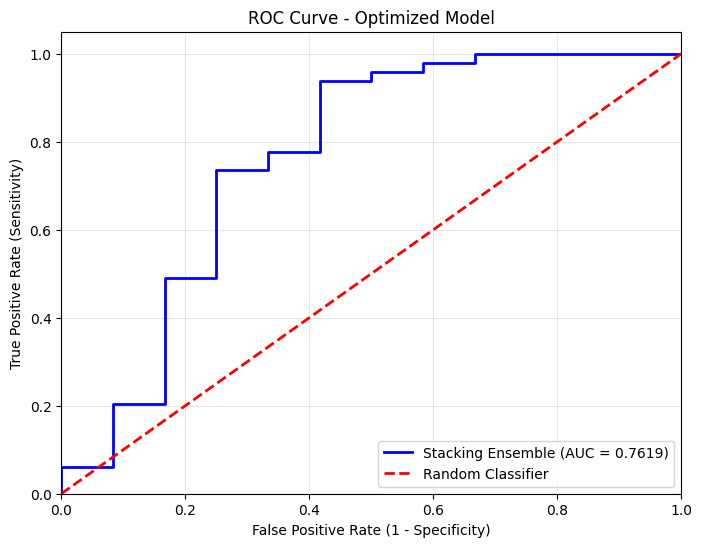

 ROC curve saved to reports/figures/optimized_roc_curve.png


In [33]:
# Cell 12: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'Stacking Ensemble (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Optimized Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('reports/figures/optimized_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(" ROC curve saved to reports/figures/optimized_roc_curve.png")

Confusion Matrix Heatmap

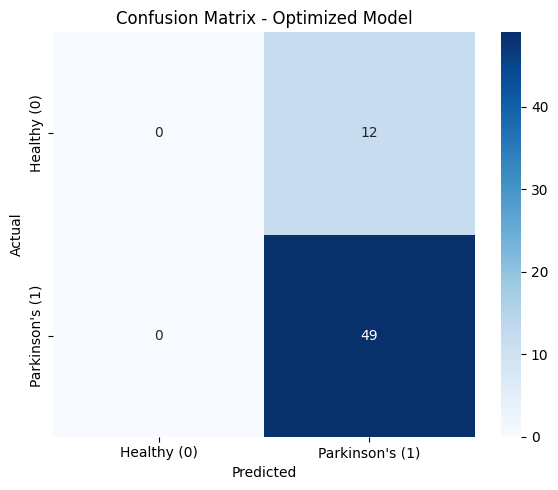

 Confusion matrix saved to reports/figures/optimized_confusion_matrix.png


In [34]:
# Cell 13: Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Parkinson\'s (1)'],
            yticklabels=['Healthy (0)', 'Parkinson\'s (1)'])
plt.title('Confusion Matrix - Optimized Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('reports/figures/optimized_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved to reports/figures/optimized_confusion_matrix.png")

Save Final Production Model

In [36]:
# Cell: Calculate missing metrics before saving
from sklearn.metrics import matthews_corrcoef

# Calculate MCC if not already defined
try:
    mcc
except NameError:
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"MCC calculated: {mcc:.4f}")

# Calculate specificity if not already defined
try:
    specificity
except NameError:
    cm_temp = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm_temp.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"Specificity calculated: {specificity:.4f}")

print("\n All metrics ready for saving")

MCC calculated: 0.0000

 All metrics ready for saving


In [37]:
# Cell 14: Save all necessary files
print("="*60)
print("SAVING PRODUCTION FILES")
print("="*60)

# Save model
joblib.dump(stacking, 'models/production_model.joblib')
print(" Model saved: models/production_model.joblib")

# Save scaler
joblib.dump(scaler, 'models/production_scaler.joblib')
print(" Scaler saved: models/production_scaler.joblib")

# Save feature selector
joblib.dump(rfecv, 'models/feature_selector.joblib')
print(" Feature selector saved: models/feature_selector.joblib")

# Save results
results_summary = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'auc': auc,
    'mcc': mcc,
    'specificity': specificity,
    'confusion_matrix': cm.tolist()
}

import json
with open('reports/final_results.json', 'w') as f:
    json.dump(results_summary, f, indent=4)
print(" Results saved: reports/final_results.json")

print("\n Optimization complete! Production model ready for GUI deployment.")

SAVING PRODUCTION FILES
 Model saved: models/production_model.joblib
 Scaler saved: models/production_scaler.joblib
 Feature selector saved: models/feature_selector.joblib
 Results saved: reports/final_results.json

 Optimization complete! Production model ready for GUI deployment.
